# Parcial David Betancur Ramirez

## Grupo 1 de Variables

# Importar librerias y extensiones

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import sklearn

from pandas import DataFrame

import warnings
warnings.filterwarnings('ignore')

## Extensión de pandas

In [3]:
%run ./extensions/pandas-missing-extension.ipynb

# Datos (nhanes)

National Health and Nutrition Examination Survey

Extraer datos

In [4]:
nhanes_raw_df = pd.read_csv('./datasets/nhanes.csv')
nhanes_raw_df.head()

,SEQN,general_health_condition,ever_breastfed_or_fed_breastmilk,age_stopped_breastfeedingdays,age_first_fed_formuladays,age_stopped_receiving_formuladays,age_started_other_foodbeverage,age_first_fed_milkdays,type_of_milk_first_fed_whole_milk,type_of_milk_first_fed2_milk,...,days_smoked_cigs_during_past30_days,avg_cigarettesday_during_past30_days,tried_to_quit_smoking,times_stopped_smoking_cigarettes,how_long_were_you_able_to_stop_smoking,unit_of_measure_dayweekmonthyear_2_smq,current_selfreported_height_inches,current_selfreported_weight_pounds,tried_to_lose_weight_in_past_year,times_lost10_lbs_or_more_to_lose_weight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Seleccionar variables correspondientes al Grupo 1 y renombrarlas

In [5]:
nhanes_grupo1_df = nhanes_raw_df.copy()

nhanes_grupo1_df = nhanes_grupo1_df.select_columns(
  "total_number_of_people_in_the_family",
  "age_in_years_at_screening",
  "gender",
  "taking_insulin_now",
  "weight_kg",
  "standing_height_cm",
  "blood_cadmium_ugl",
  "total_saturated_fatty_acids_gm_dr1_tot",
  "diastolic_blood_pres2_nd_rdg_mm_hg",
  "protein_gm_dr2_tot",
  "energy_kcal_dr2_tot",
  "general_health_condition",
).rename_columns({
  "total_number_of_people_in_the_family": "family_size",
  "age_in_years_at_screening": "age",
  "gender": "gender",
  "taking_insulin_now": "taking_insulin",
  "weight_kg": "weight",
  "standing_height_cm": "height",
  "blood_cadmium_ugl": "bcu",
  "total_saturated_fatty_acids_gm_dr1_tot": "sfa",
  "diastolic_blood_pres2_nd_rdg_mm_hg": "db_pressure",
  "protein_gm_dr2_tot": "protein",
  "energy_kcal_dr2_tot": "energy",
  "general_health_condition": "health_condition"
})

nhanes_grupo1_df

,family_size,age,gender,taking_insulin,weight,height,bcu,sfa,db_pressure,protein,energy,health_condition
0,5,2.0,Female,0.0,13.7,88.6,NaN,NaN,NaN,NaN,NaN,NaN
1,4,2.0,Male,0.0,13.9,94.2,0.07,11.372,NaN,30.49,1356.0,NaN
2,1,66.0,Female,0.0,79.5,158.3,0.24,16.435,NaN,38.52,1235.0,Good
3,5,18.0,Male,0.0,66.3,175.7,0.21,35.169,70.0,NaN,NaN,Very good
4,7 or more people in the Family,13.0,Male,0.0,45.4,158.4,0.14,33.252,46.0,92.03,1794.0,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
8361,2,70.0,Female,0.0,49.0,156.5,0.61,7.652,78.0,47.56,1054.0,Very good
8362,1,42.0,Male,0.0,97.4,164.9,0.21,25.831,76.0,NaN,NaN,Fair or
8363,7 or more people in the Family,41.0,Female,0.0,69.1,162.6,0.32,20.526,72.0,66.97,1835.0,Good
8364,4,14.0,Female,0.0,111.9,156.6,0.11,23.027,60.0,58.08,1617.0,Very good


Info del Dataset

In [6]:
nhanes_grupo1_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   family_size       8366 non-null   str    
 1   age               8366 non-null   float64
 2   gender            8366 non-null   str    
 3   taking_insulin    8365 non-null   float64
 4   weight            8242 non-null   float64
 5   height            8016 non-null   float64
 6   bcu               7513 non-null   float64
 7   sfa               7285 non-null   float64
 8   db_pressure       6563 non-null   float64
 9   protein           6323 non-null   float64
 10  energy            6323 non-null   float64
 11  health_condition  5964 non-null   str    
dtypes: float64(9), str(3)
memory usage: 784.4 KB


# Datos nulos

## Analisis general de cantidad de nulos

In [7]:
print(f"El tamaño del conjunto de datos es {nhanes_grupo1_df.shape}")
print(f"El número total de valores nulos explicitos es {nhanes_grupo1_df.missing.number_missing()}")
print(f"La cantidad de datos no nulos explicitos es: {nhanes_grupo1_df.missing.number_complete()}")

El tamaño del conjunto de datos es (8366, 12)
El número total de valores nulos explicitos es 10700
La cantidad de datos no nulos explicitos es: 89692


## Analisis de datos nulos por columna

In [8]:
nhanes_grupo1_df.missing.missing_variable_summary().sort_values(by='pct_missing', ascending=False)

,variable,n_missing,n_cases,pct_missing
11,health_condition,2402,8366,28.711451
9,protein,2043,8366,24.420273
10,energy,2043,8366,24.420273
8,db_pressure,1803,8366,21.551518
7,sfa,1081,8366,12.921348
6,bcu,853,8366,10.196032
5,height,350,8366,4.183600
4,weight,124,8366,1.482190
3,taking_insulin,1,8366,0.011953
2,gender,0,8366,0.000000


Grafico nulos por columna

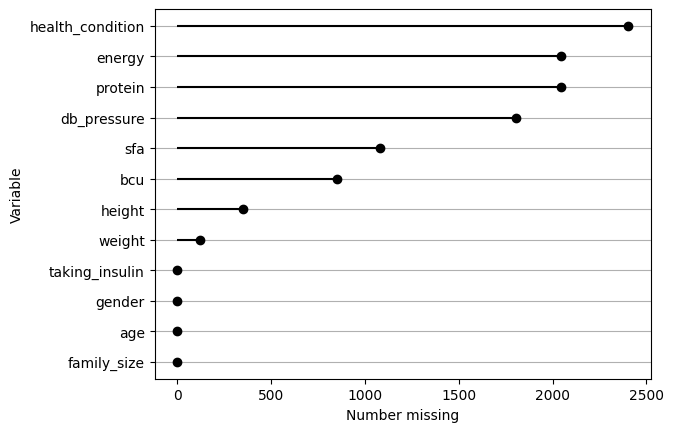

In [9]:
nhanes_grupo1_df.missing.missing_variable_plot()

El grafico permite compararar la cantidad de datos nulos que hay por columna, es una ayuda grafica que se completa con la tabla anterior.

Se puede notar facilmente de que health_condition es la que mas valores nulos tiene con 2402 nulos y lo siguen las variables energy y protein que juntos tienen la misma cantidad de datos nulos, 2043.

**Analisis general de los datos nulos por columna**: Aunque hay una gran cantidad de datos nulos en algunas columnas, están dentro de un rango razonable en que se pueden completar estos valores, ninguna variable se debe de eliminar ya que la variable con mas nulos, *health_condition* cuenta con 28.71% de valores nulos. Si fueran más de 40% si deberia de eliminarse.

## Analisis de datos nulos por fila

In [10]:
missing_case = nhanes_grupo1_df.missing.missing_case_summary().sort_values(by='pct_missing', ascending=False)

print("Tabla resumen de filas con datos faltantes:")
display(missing_case)

print("Tabla de cantidad de valores faltantes por fila:")
display(missing_case["n_missing"].value_counts())

Tabla resumen de filas con datos faltantes:


,case,n_missing,pct_missing
5863,5863,8,57.142857
5632,5632,8,57.142857
108,108,8,57.142857
874,874,8,57.142857
4355,4355,8,57.142857
...,...,...,...
3538,3538,0,0.000000
8345,8345,0,0.000000
22,22,0,0.000000
19,19,0,0.000000


Tabla de cantidad de valores faltantes por fila:


n_missing
0    4444
2    1293
1     877
3     668
4     483
5     366
6     179
7      51
8       5
Name: count, dtype: int64

Grafico de Cantidad de filas por Cantidad de valores nulos

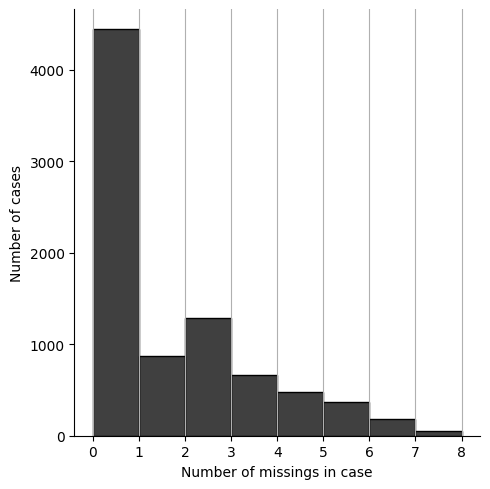

In [11]:
nhanes_grupo1_df.missing.missing_case_plot()

El grafico permite visualizar la cantidad de valores nulos que tienen las filas.

Se puede evidenciar que la mayoria de filas no tienen valores nulos. Además de que hay 5 filas que tienen 8 de 12 columnas con valores nulos.

Grafico de Datos nulos por fila

<Axes: >

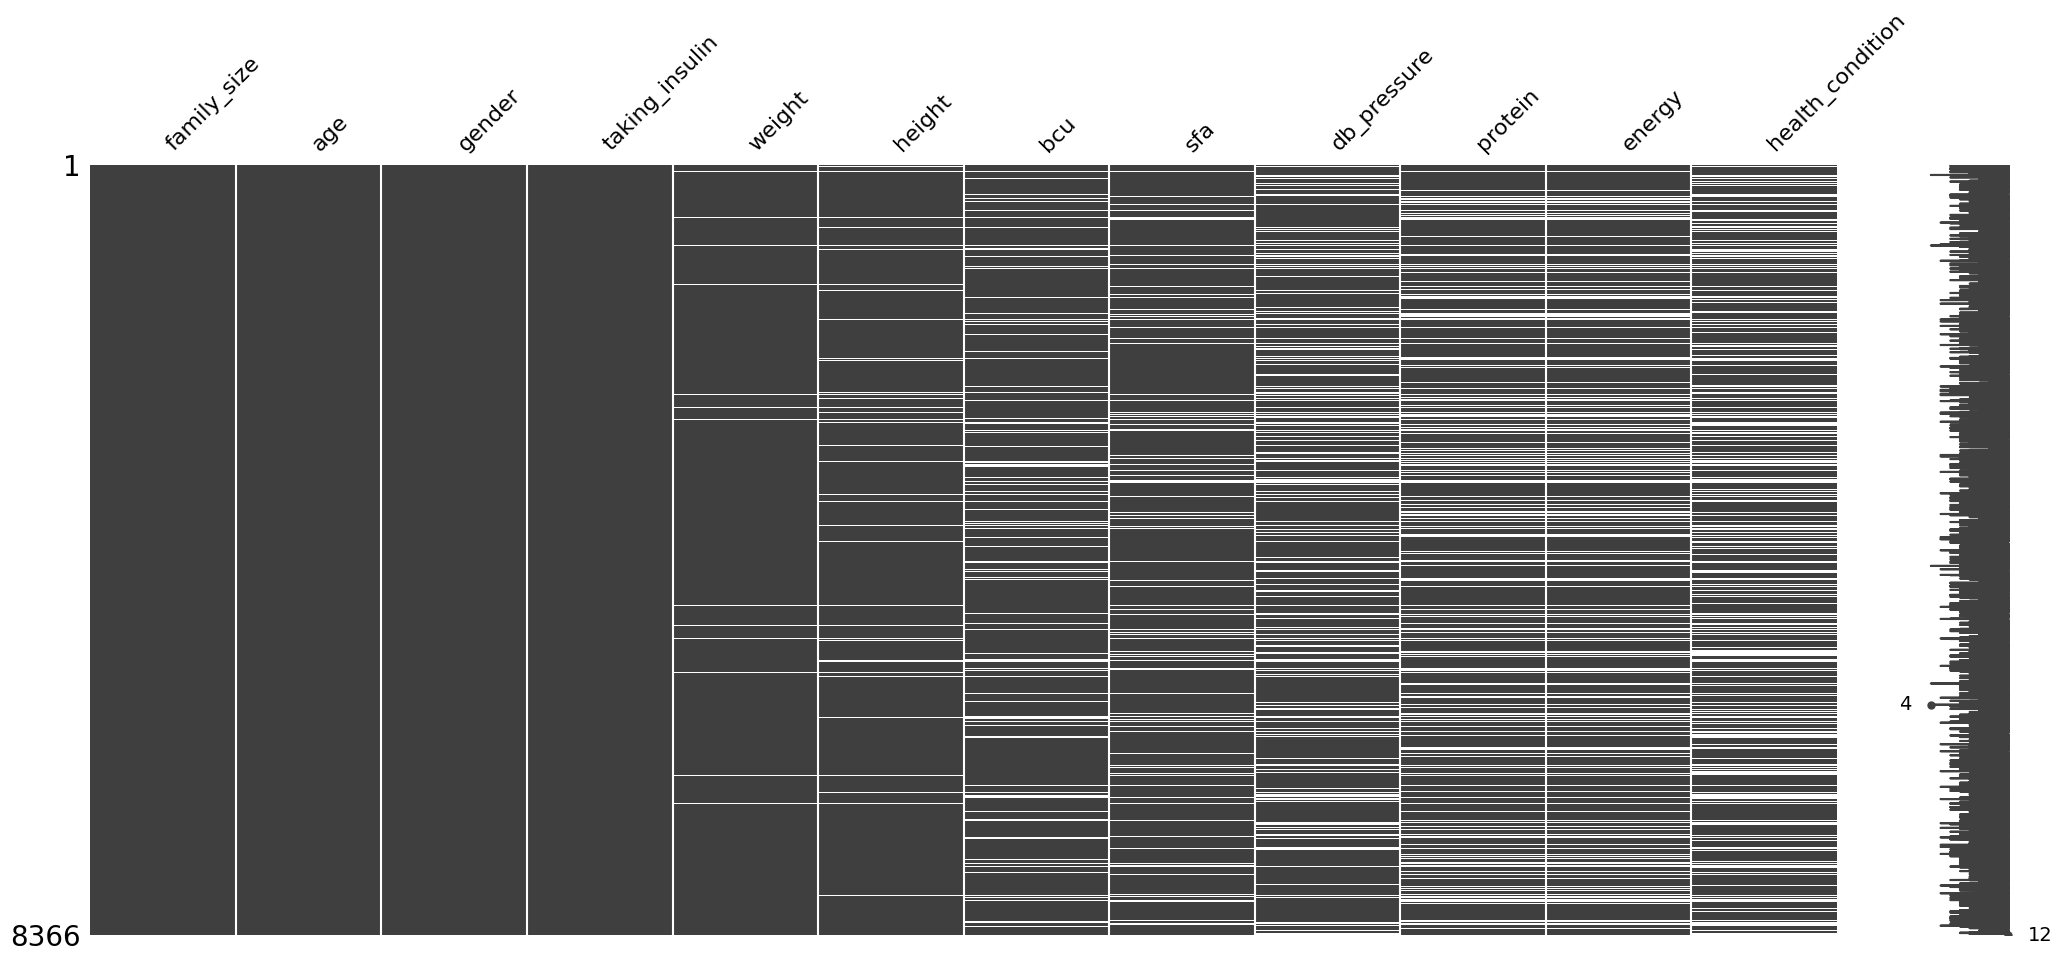

In [12]:
msno.matrix(df = nhanes_grupo1_df)

El grafico anterior puede permitir ver patrones de la ubicación de los datos nulos, pero en este caso no se ve ningun patron claro con el que se pueda hacer algun analisis o conclusión.

## Analisis de Correlación de los datos nulos

<Axes: >

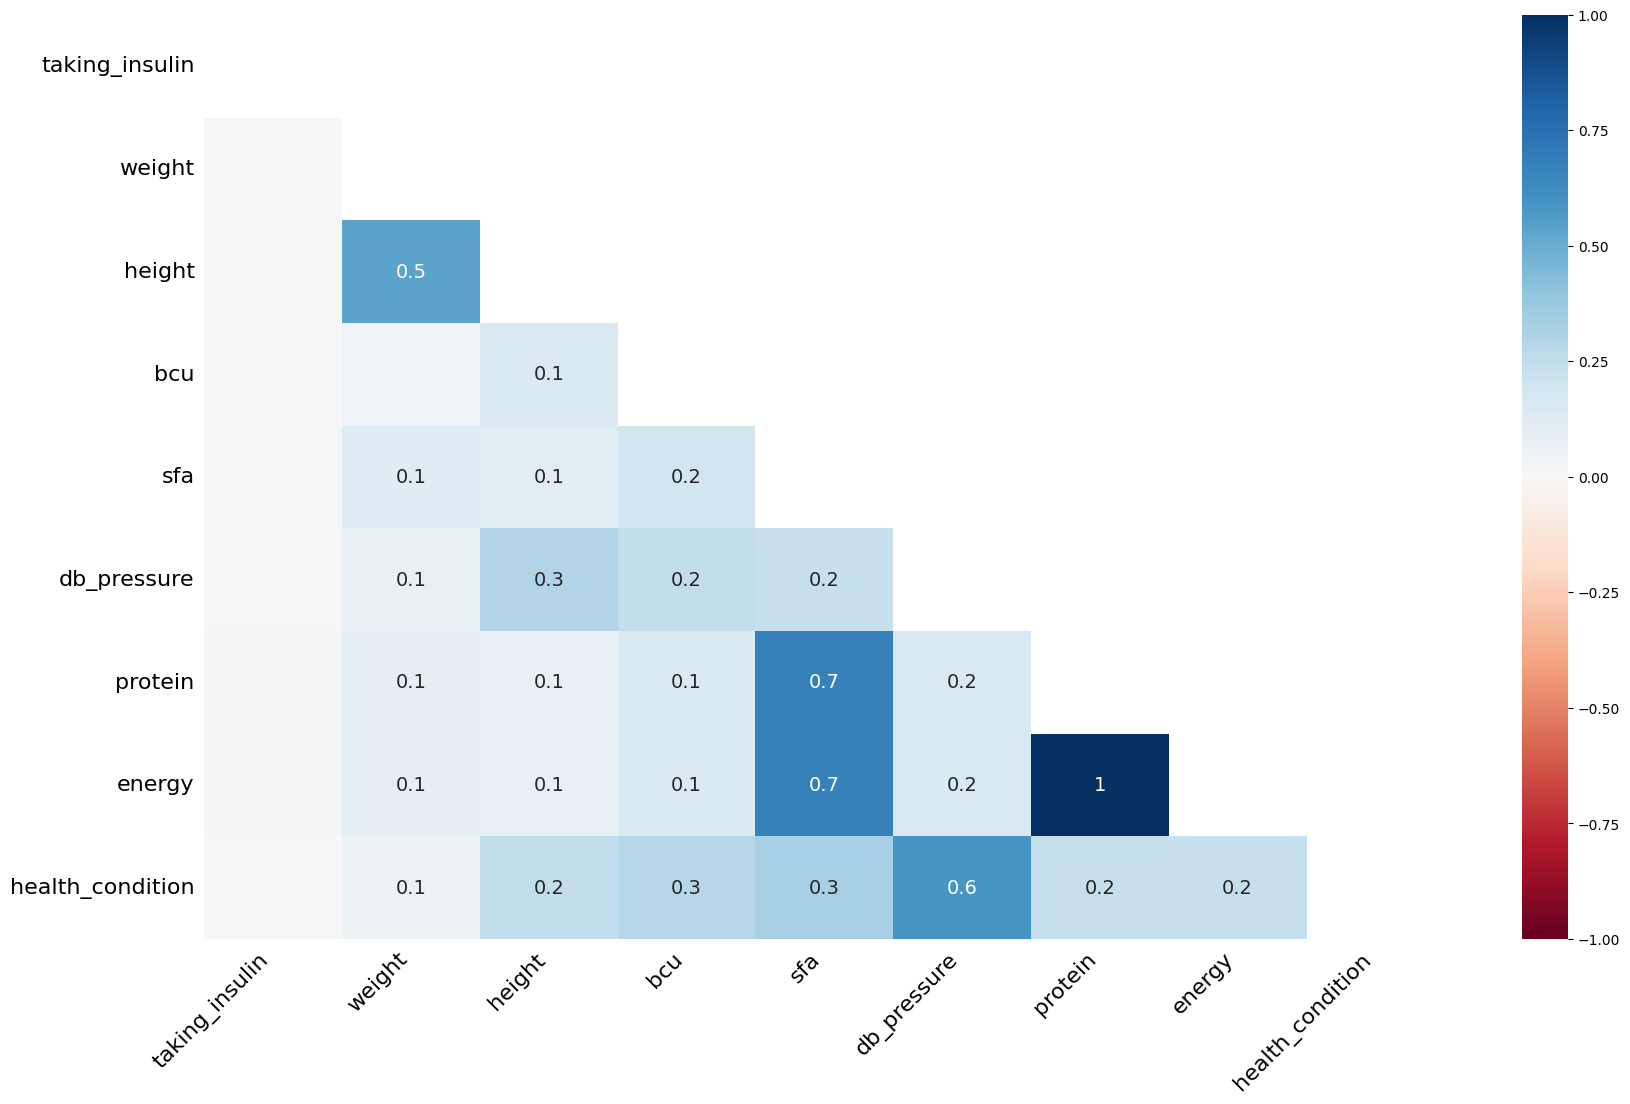

In [13]:
msno.heatmap(df = nhanes_grupo1_df)

Del mapa de correlación de los datos nulos se pueden extraer las siguientes relaciones importantes.

1. Cuando energy tiene un valor nulo, siempre hay un valor nulo en protein
2. Cuando sfa tiene un valor nulo, en el 70% de las veces hay nulos tambien en protein y energy. Tambien se complementa con el primer analisis y tiene sentido de que ambas variables sea igual.
3. Otras correlaciones altas a tener en cuenta, pero no tan relevantes como las anteriores, se puede tener entre health_condition y db_pressure con 0.6 y height con wight con 0.5.

# Analisis Univariado y Distribuciones

## Comportamiento variables categoricas

In [14]:
nhanes_grupo1_df.describe(include=['object', 'str']).transpose()

,count,unique,top,freq
family_size,8366,7,4,1658
gender,8366,2,Female,4272
health_condition,5964,5,Good,2454


### Analisis univariado variables categoricas

In [15]:
def show_categorical_distribution(col=str):
  print(f"\n{'═'*65}")
  print(f"  {col}")
  print(f"{'═'*65}")

  n_nulls = nhanes_grupo1_df[col].isna().sum()
  display(nhanes_grupo1_df[col].describe())
  print(f"  Valores nulos: {n_nulls}")

  plt.pie(
    x = nhanes_grupo1_df[col].value_counts(),
    labels = nhanes_grupo1_df[col].value_counts().index,
    autopct='%1.1f%%'
  )
  plt.title(f'Distribución de {col} en el conjunto de datos')
  plt.show()

#### family_size


═════════════════════════════════════════════════════════════════
  family_size
═════════════════════════════════════════════════════════════════


count     8366
unique       7
top          4
freq      1658
Name: family_size, dtype: object

  Valores nulos: 0


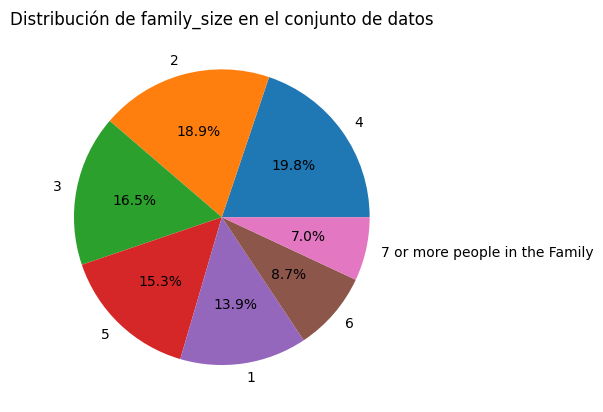

In [16]:
show_categorical_distribution('family_size')

No hay errores, el unico detalle que puede mejorar las categorias es renombrar *7 or more people in the Family* por *7+*, hace referencia a lo mismo y es un nombre más corto

In [17]:
nhanes_grupo1_df['family_size'] = nhanes_grupo1_df['family_size'].replace({ "7 or more people in the Family": "7+" })

nhanes_grupo1_df['family_size'].unique()

<StringArray>
['5', '4', '1', '7+', '2', '3', '6']
Length: 7, dtype: str

#### gender


═════════════════════════════════════════════════════════════════
  gender
═════════════════════════════════════════════════════════════════


count       8366
unique         2
top       Female
freq        4272
Name: gender, dtype: object

  Valores nulos: 0


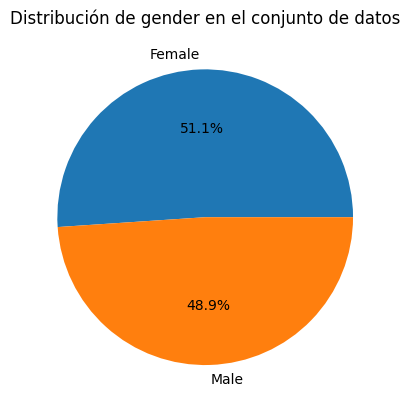

In [18]:
show_categorical_distribution('gender')

#### health_condition


═════════════════════════════════════════════════════════════════
  health_condition
═════════════════════════════════════════════════════════════════


count     5964
unique       5
top       Good
freq      2454
Name: health_condition, dtype: object

  Valores nulos: 2402


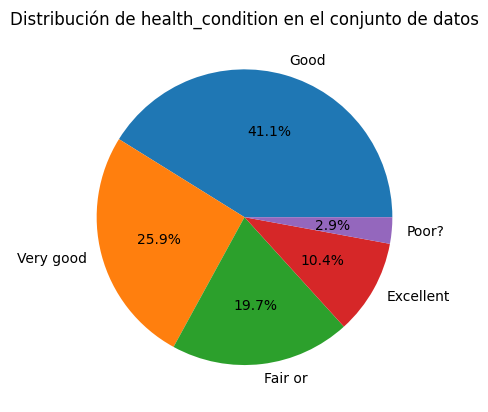

In [19]:
show_categorical_distribution('health_condition')

No hay errores, el unico detalle que puede mejorar las categorias es hacer los siguientes renombramientos de categorias:
- *Fair or* por *Fair*
- *Poor?* por *Poor*

Ya que en ambos casos hay palabras o caracteres que sobran y es para tener mejores valores de las categorias

In [20]:
nhanes_grupo1_df['health_condition'] = (
  nhanes_grupo1_df['health_condition'].replace({
    "Fair or": "Fair",
    "Poor?": "Poor"
  })
)

nhanes_grupo1_df['health_condition'].unique()

<StringArray>
[nan, 'Good', 'Very good', 'Fair', 'Excellent', 'Poor']
Length: 6, dtype: str

Como se evidenció anteriormente, la variable health_condition cuenta con 28.71% de datos faltantes.

Teniendo en cuenta esto y de que la matriz de correlación de datos nulos no tiene valores significativos se puede concluir que estos valores faltantes son MAR (Missing At Random).

#### Re-analisis despues de mejoras de las variables categorias


═════════════════════════════════════════════════════════════════
  family_size
═════════════════════════════════════════════════════════════════


count     8366
unique       7
top          4
freq      1658
Name: family_size, dtype: object

  Valores nulos: 0


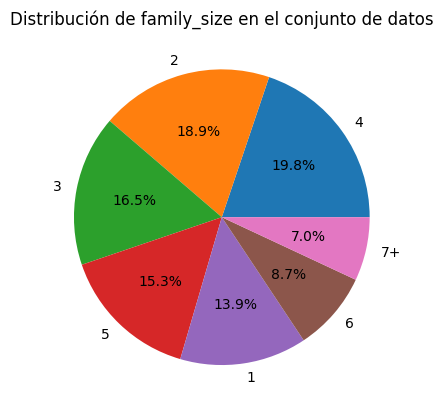


═════════════════════════════════════════════════════════════════
  gender
═════════════════════════════════════════════════════════════════


count       8366
unique         2
top       Female
freq        4272
Name: gender, dtype: object

  Valores nulos: 0


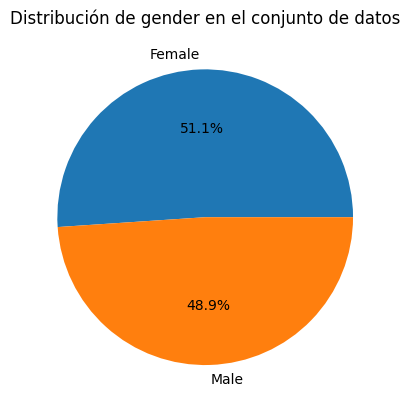


═════════════════════════════════════════════════════════════════
  health_condition
═════════════════════════════════════════════════════════════════


count     5964
unique       5
top       Good
freq      2454
Name: health_condition, dtype: object

  Valores nulos: 2402


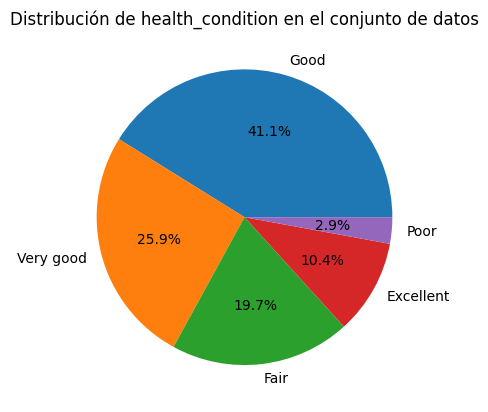

In [21]:
cat_cols = nhanes_grupo1_df.select_dtypes(include=['object', 'str']).columns

for col in cat_cols:
  show_categorical_distribution(col)

## Comportamiento variables numericos

In [22]:
nhanes_grupo1_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,8366.0,35.830026,24.905061,1.000000e+00,12.000,33.000,59.000,80.000
taking_insulin,8365.0,0.029528,0.169291,0.000000e+00,0.000,0.000,0.000,1.000
weight,8242.0,67.499260,31.377152,8.300000e+00,48.700,69.200,86.500,242.600
height,8016.0,156.593401,22.257858,7.830000e+01,151.400,161.900,171.200,197.700
bcu,7513.0,0.373626,0.503434,7.000000e-02,0.120,0.220,0.420,13.030
sfa,7285.0,26.566194,17.065502,5.397605e-79,14.989,23.037,34.381,195.852
db_pressure,6563.0,68.298339,16.160332,5.397605e-79,60.000,70.000,78.000,136.000
protein,6323.0,70.866505,38.429392,5.397605e-79,44.995,63.790,88.075,345.530
energy,6323.0,1832.226791,886.204553,5.397605e-79,1226.500,1699.000,2261.500,11241.000


### Analisis univariado variables numericas

In [23]:
def show_numerical_distribution(col=str):
  column_values = nhanes_grupo1_df[col]
  non_null_values = column_values.dropna()
  n_nulls = column_values.isna().sum()

  media = non_null_values.mean()
  mediana = non_null_values.median()
  q1 = non_null_values.quantile(0.25)
  q3 = non_null_values.quantile(0.75)
  iqr = q3 - q1
  lim_inf = q1 - 1.5 * iqr
  lim_sup = q3 + 1.5 * iqr

  real_min = non_null_values.min()
  real_max = non_null_values.max()
  iqr_vis_inf = max(lim_inf, real_min)
  iqr_vis_sup = min(lim_sup, real_max)

  outliers_mask = (non_null_values < lim_inf) | (non_null_values > lim_sup)
  n_outliers = outliers_mask.sum()

  print(f"{'═'*65}")
  print(f"  {col}")
  print(f"{'═'*65}")
  print(f"Cantidad de datos nulos: {n_nulls}")
  print(f"IQR (Q3 - Q1): {iqr:.4f}")
  print(f"Rango actual [{real_min:.4f}, {real_max:.4f}]")
  print(f"Rango IQR permitido [{lim_inf:.4f}, {lim_sup:.4f}]")
  print(f"Valores fuera del rango IQR: {n_outliers} de {len(non_null_values)}")

  fig, ax = plt.subplots(figsize=(9, 4))
  sns.histplot(data=nhanes_grupo1_df, x=col, kde=True, ax=ax, color='skyblue')
  ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
  ax.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f'Mediana: {mediana:.2f}')

  if iqr_vis_inf < iqr_vis_sup:
      ax.axvspan(iqr_vis_inf, iqr_vis_sup, color='orange', alpha=0.12, label='Rango IQR permitido')

  ax.set_xlim(real_min, real_max)
  ax.set_title(f"Distribución de {col}", fontsize=13)
  ax.set_xlabel(col)
  ax.set_ylabel("Frecuencia")
  ax.legend()
  fig.tight_layout()
  plt.show()

#### age

Edad del individuo

═════════════════════════════════════════════════════════════════
  age
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 0
IQR (Q3 - Q1): 47.0000
Rango actual [1.0000, 80.0000]
Rango IQR permitido [-58.5000, 129.5000]
Valores fuera del rango IQR: 0 de 8366


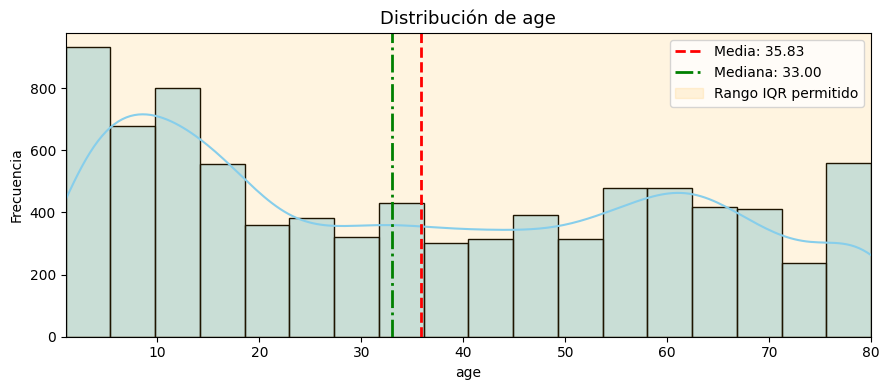

In [24]:
show_numerical_distribution('age')

No hay nada raro en la columna age, su media mediana y distribución son consistentes con la naturaleza de la variable.

Además, no tiene valores nulos.

#### taking_insulin

Si el individuo está o no está tomando insulina

═════════════════════════════════════════════════════════════════
  taking_insulin
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 1
IQR (Q3 - Q1): 0.0000
Rango actual [0.0000, 1.0000]
Rango IQR permitido [0.0000, 0.0000]
Valores fuera del rango IQR: 247 de 8365


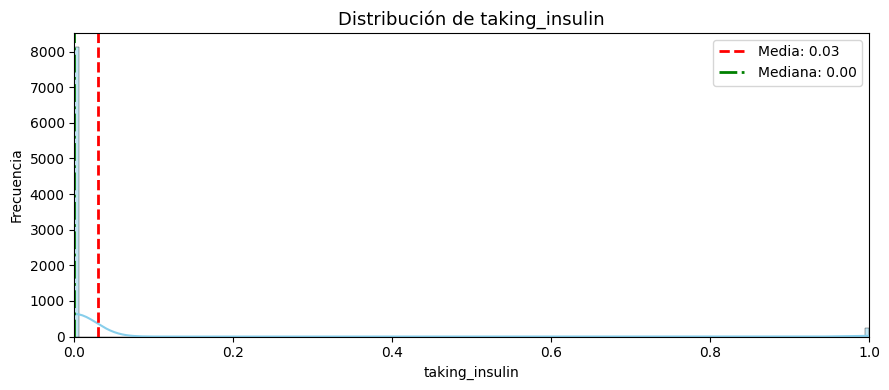

In [25]:
show_numerical_distribution('taking_insulin')

In [26]:
display(nhanes_grupo1_df['taking_insulin'].unique())

display(nhanes_grupo1_df['taking_insulin'].info())

array([ 0.,  1., nan])

<class 'pandas.Series'>
RangeIndex: 8366 entries, 0 to 8365
Series name: taking_insulin
Non-Null Count  Dtype  
--------------  -----  
8365 non-null   float64
dtypes: float64(1)
memory usage: 65.5 KB


None

##### Pasar de float64 a str

Por la naturaleza de los datos de la columna taking_insulin debería de ser una variable booleana, no numerica. 

Como tiene 1 dato nulo, manejarlo como boolean (bool con nulos) genera problemas para la importación con modelos de regresión, por lo que se va a transformar a *str* ya que maneja una logica más similar mientras se trata el dato nulo de esta columna para poder transformarlo luego a tipo bool.

In [27]:
# Reemplazar NaN por None de forma explícita
nhanes_grupo1_df['taking_insulin'] = nhanes_grupo1_df['taking_insulin'].where(
  nhanes_grupo1_df['taking_insulin'].notna(),
  None
)

# Convertir 0/1 a booleano preservando faltantes
nhanes_grupo1_df['taking_insulin'] = (
  nhanes_grupo1_df['taking_insulin']
  .map({0.0: 'False', 1.0: 'True' })
  .astype('str')
  )

print('Valores únicos después de convertir:')
display(nhanes_grupo1_df['taking_insulin'].unique())
print('Tipo final de la columna:', nhanes_grupo1_df['taking_insulin'].dtype)

Valores únicos después de convertir:


<StringArray>
['False', 'True', nan]
Length: 3, dtype: str

Tipo final de la columna: str


##### Conclusiones

- La columna taking_insulin ahora es de tipo boolean, que tiene más sentido para los datos que tiene.

- Tiene unicamente 1 dato faltante, por lo que se puede interpretar como un dato nulo *MCAR* (Missing Completly At Random)

#### weight

Peso del individuo

═════════════════════════════════════════════════════════════════
  weight
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 124
IQR (Q3 - Q1): 37.8000
Rango actual [8.3000, 242.6000]
Rango IQR permitido [-8.0000, 143.2000]
Valores fuera del rango IQR: 112 de 8242


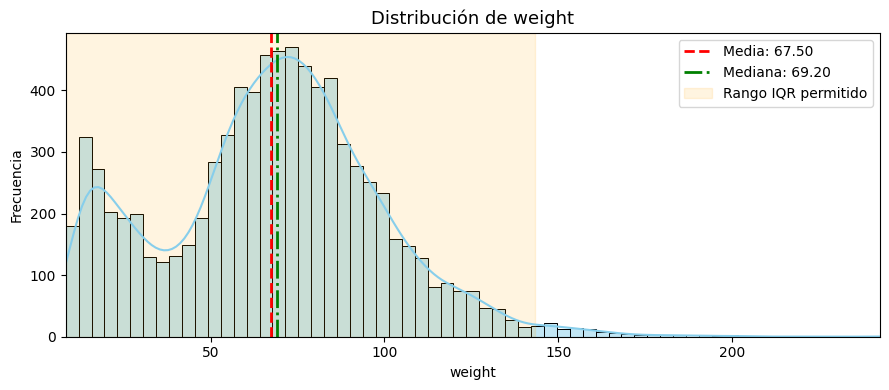

In [28]:
show_numerical_distribution('weight')

##### Analisis de outliers

Es normal que la variable weight tenga una cola a la derecha, pero igualmente se hará un analisis más detallado de los valores que se encuentran fuera del rango IQR para determinar si son nulos implicitos.

In [29]:
nhanes_grupo1_df[['age', 'weight', 'height']].sort_values(by=['weight'], ascending=False).head(20)

,age,weight,height
3825,35.0,242.6,167.8
8203,67.0,219.6,161.3
379,57.0,204.4,165.3
5779,18.0,200.9,166.4
2741,61.0,198.7,177.1
8005,33.0,197.7,170.3
2620,30.0,191.4,175.8
3737,24.0,191.3,175.7
7910,39.0,186.5,182.4
4114,52.0,185.0,165.3


Aunque hay algunos valores fuera del IQR, ninguno parece ser un nulo implicito.

##### Conclusiones

- Los outliers no son nulos implicitos.
- Se tienen 124 datos faltantes, los cuales parecen ser MAR (Missing At Random).

#### height

Altura del individuo

═════════════════════════════════════════════════════════════════
  height
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 350
IQR (Q3 - Q1): 19.8000
Rango actual [78.3000, 197.7000]
Rango IQR permitido [121.7000, 200.9000]
Valores fuera del rango IQR: 822 de 8016


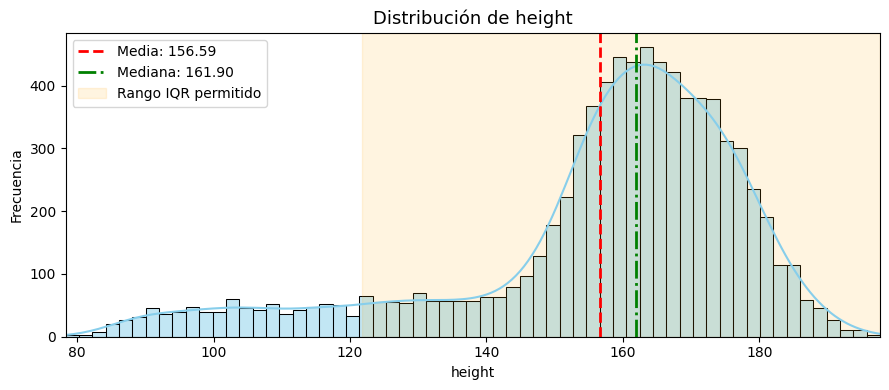

In [30]:
show_numerical_distribution('height')

##### Analisis de outliers

Es normal que se tengan más datos de personas mayores que de niños o bebes, es por esto que se puede ver que la media y mediana estan en aproximadamente 1.60 que es una altura normal para las personas.

Igualmente se hará un pequeño analisis de los datos fuera el IQR para determinar si son nulos implicitos

In [31]:
nhanes_grupo1_df[['age', 'height']].sort_values(by=['height'], ascending=True).head(20)

,age,height
1307,2.0,78.3
4944,2.0,78.5
2294,2.0,80.0
843,2.0,81.3
5009,2.0,81.6
8351,2.0,82.5
5191,2.0,82.6
5296,2.0,83.2
1913,2.0,83.3
5098,2.0,83.6


##### Conclusiones

- Los outliers no son nulos implicitos, ya que la edad de las alturas más pequeñas corresponden a bebes, lo cual tiene sentido.
- Se tienen 350 datos faltantes, los cuales parecen ser MAR (Missing At Random).

#### bcu
Concentración de cadmio en sangre, medida en microgramos por litro (µg/L).

═════════════════════════════════════════════════════════════════
  bcu
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 853
IQR (Q3 - Q1): 0.3000
Rango actual [0.0700, 13.0300]
Rango IQR permitido [-0.3300, 0.8700]
Valores fuera del rango IQR: 677 de 7513


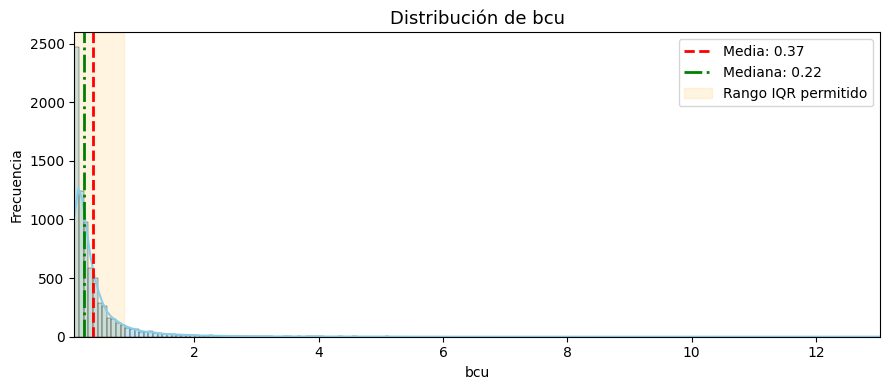

In [32]:
show_numerical_distribution('bcu')

##### Analisis de outliers

| Nivel (µg/L) | Interpretación                              |
| ------------ | ------------------------------------------- |
| <0.5         | típico población general                    |
| 1–3          | exposición elevada                          |
| 3–10         | fumadores intensos                          |
| >10          | exposición ocupacional o acumulación severa |


Lo normal en este tipo de variables es que la mayoria de personas se encuentren en los mismos niveles y de que algunas personas tengan valores fuera de lo normal, por lo que se hará un analisis de los outliers para determinar si corresponden a nulos implicitos

In [33]:
nhanes_grupo1_df['bcu'].sort_values(ascending=False).head(10)

664     13.03
857      7.50
3414     5.42
6146     5.27
7702     5.13
6824     5.13
1984     4.65
1967     4.60
3636     4.57
769      4.55
Name: bcu, dtype: float64

In [34]:
nhanes_grupo1_df[nhanes_grupo1_df["bcu"] == 13.03]

,family_size,age,gender,taking_insulin,weight,height,bcu,sfa,db_pressure,protein,energy,health_condition
664,1,71.0,Female,False,94.5,161.8,13.03,28.347,66.0,83.93,1884.0,Good


El individuo con id 664 tiene un valor de bcu de 13.03, el cual es un valor muy alto y alejado del resto, pero no imposible, por lo que no se va a determinar como un nulo implicito

In [35]:
nhanes_grupo1_df["bcu"].value_counts().head(20)

bcu
0.07    1396
0.14     236
0.13     227
0.12     218
0.10     211
0.15     204
0.17     193
0.18     191
0.16     191
0.11     185
0.20     176
0.19     152
0.22     152
0.23     146
0.24     143
0.21     140
0.25     126
0.26     117
0.29     104
0.31     102
Name: count, dtype: int64

<Axes: xlabel='bcu', ylabel='Count'>

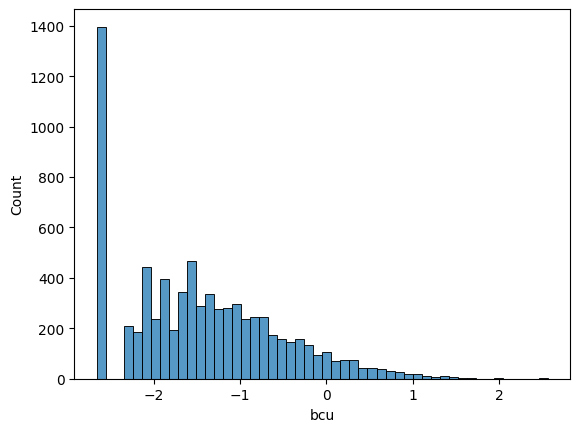

In [36]:
sns.histplot(np.log(nhanes_grupo1_df["bcu"]), bins=50)

En NHANES es común que ocurra lo siguiente:

- Existe un LOD (Limit of Detection) del laboratorio.
- Cuando el valor real está por debajo del límite detectable, por lo que guarda un valor muy pequeño que lo representa.

Por esta razon, hay tantos valores con 0.07

##### Conclusiones

- Los outliers no son nulos implicitos.
- Se tiene muchos individuos con el valor de 0.07, que aunque es raro puede deberse al LOD (Limit of Detection) de la prueba, por lo que aunque mueva las estadisticas, no se pueden considerar como outliers
- Se tienen 853 datos faltantes, los cuales parecen ser MAR (Missing At Random).

#### sfa

Gramos totales de ácidos grasos saturados consumidos en el Day-1 Dietary Recall (DR1).

═════════════════════════════════════════════════════════════════
  sfa
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 1081
IQR (Q3 - Q1): 19.3920
Rango actual [0.0000, 195.8520]
Rango IQR permitido [-14.0990, 63.4690]
Valores fuera del rango IQR: 242 de 7285


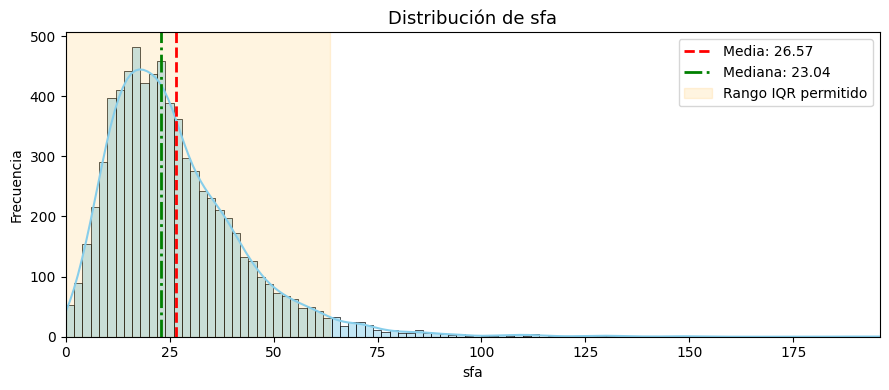

In [37]:
show_numerical_distribution('sfa')

##### Analisis de outliers

| Rango (g/día) | Interpretación                         |
| ------------- | -------------------------------------- |
| 0 – 5         | muy bajo                               |
| 5 – 25        | típico población                       |
| 25 – 50       | alto                                   |
| 50 – 80       | muy alto                               |
| >80           | extremadamente alto pero posible       |
| >120          | raro (dietas extremas / error posible) |


Lo normal en este tipo de variables es que la mayoria de personas se encuentren en los mismos niveles y de que algunas personas tengan valores fuera de lo normal, por lo que se hará un analisis de los outliers para determinar si corresponden a nulos implicitos

In [38]:
nhanes_grupo1_df['sfa'].sort_values(ascending=False).head(20)

3737    195.852
3439    188.012
2169    154.474
6038    149.146
3114    146.872
7951    146.778
2785    139.828
907     135.209
4433    133.535
3530    131.653
3993    131.034
5795    129.764
4035    128.438
7492    127.375
4338    125.656
5924    125.529
594     123.464
1579    118.778
5172    116.687
3441    116.527
Name: sfa, dtype: float64

##### Conclusiones

- Los outliers no son nulos implicitos, aunque los valores superiores a 120 son extremos y muy raros, no son imposibles.
- Se tienen 1081 datos faltantes, los cuales parecen ser MAR (Missing At Random).

#### db_pressure

Presión diastólica medida en el segundo intento durante el examen clínico.

═════════════════════════════════════════════════════════════════
  db_pressure
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 1803
IQR (Q3 - Q1): 18.0000
Rango actual [0.0000, 136.0000]
Rango IQR permitido [33.0000, 105.0000]
Valores fuera del rango IQR: 197 de 6563


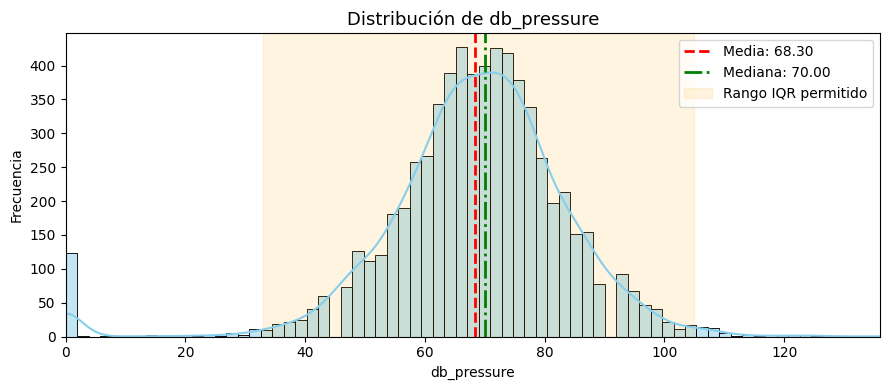

In [39]:
show_numerical_distribution('db_pressure')

##### Analisis de outliers

| Rango (mmHg) | Interpretación       |
| ------------ | -------------------- |
| <60          | baja                 |
| 60–80        | normal               |
| 80–89        | elevada              |
| 90–99        | hipertensión etapa 1 |
| 100–120      | hipertensión severa  |
| >120         | crisis hipertensiva  |

Lo normal en este tipo de variables es que la mayoria de personas se encuentren en los mismos niveles y de que algunas personas tengan valores fuera de lo normal, por lo que se hará un analisis de los outliers para determinar si corresponden a nulos implicitos

In [40]:
nhanes_grupo1_df["db_pressure"].sort_values(ascending=False).head(20)

2564    136.0
3646    128.0
6560    126.0
6061    124.0
6722    124.0
6686    122.0
1641    122.0
6352    120.0
3040    120.0
3551    116.0
5397    114.0
5860    114.0
6233    114.0
2305    112.0
1955    110.0
8034    110.0
6886    110.0
1044    110.0
577     110.0
1580    108.0
Name: db_pressure, dtype: float64

Los outliers superiores no parecen ser valores nulos implicitos, ya que no estan muy alejados unos de otro y aunque son raros, pueden ser posibles

In [41]:
nhanes_grupo1_df["db_pressure"].sort_values(ascending=True).head(20)

2072    5.397605e-79
6584    5.397605e-79
5428    5.397605e-79
3919    5.397605e-79
4646    5.397605e-79
7559    5.397605e-79
1018    5.397605e-79
1384    5.397605e-79
4809    5.397605e-79
7561    5.397605e-79
2793    5.397605e-79
2269    5.397605e-79
2273    5.397605e-79
6951    5.397605e-79
3751    5.397605e-79
1702    5.397605e-79
184     5.397605e-79
5554    5.397605e-79
515     5.397605e-79
2985    5.397605e-79
Name: db_pressure, dtype: float64

Hay varios valores demasiado bajos que deben de ser errores de medición.

Para evitar este ruido, valores debajo de 30 ya son considerados raros pero en algunos casos pueden llegar a ser posibles, pero definitivamente los inferiores a 20 ya son nulos implicitos.

In [42]:
mask_db_pressure_low_20 = nhanes_grupo1_df['db_pressure'] < 20

print('Cantidad de valores a convertir en nulos:', mask_db_pressure_low_20.sum())

nhanes_grupo1_df.loc[mask_db_pressure_low_20, 'db_pressure'] = np.nan

print('Cantidad de valores menores a 20 después del cambio:', (nhanes_grupo1_df['db_pressure'] < 20).sum())
print('Cantidad total de nulos en db_pressure:', nhanes_grupo1_df['db_pressure'].isna().sum())

Cantidad de valores a convertir en nulos: 128
Cantidad de valores menores a 20 después del cambio: 0
Cantidad total de nulos en db_pressure: 1931


##### Conclusiones

- Los outliers superiores no son nulos implicitos.
- Los outliers inferiores a 20 si eran nulos implicitos, por lo cual se convirtieron 128 datos a nulos explicitos
- Se tenían originalmente 1931 datos faltantes, los cuales parecen ser MAR (Missing At Random).
- En total, quedaron 2059 datos nulos.

#### protein

Proteína total consumida (gramos) en el recall dietario día 2

═════════════════════════════════════════════════════════════════
  protein
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 2043
IQR (Q3 - Q1): 43.0800
Rango actual [0.0000, 345.5300]
Rango IQR permitido [-19.6250, 152.6950]
Valores fuera del rango IQR: 227 de 6323


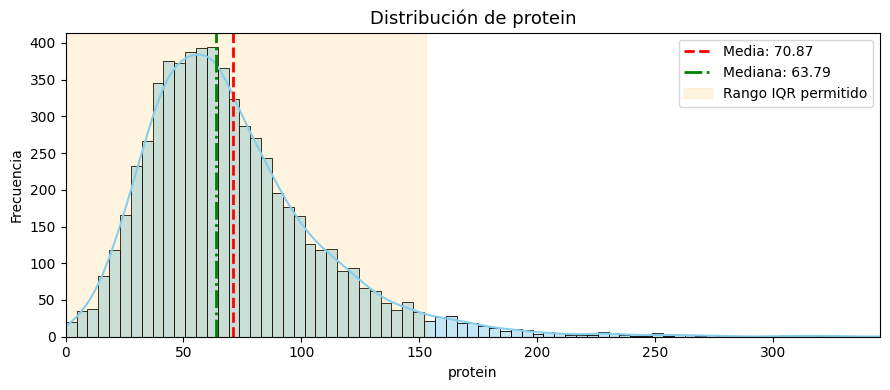

In [43]:
show_numerical_distribution('protein')

##### Analisis de outliers

| Nivel               | Proteína (g/día) |
| ------------------- | ---------------- |
| Muy bajo            | 20 – 40 g        |
| Normal              | 50 – 100 g       |
| Alto                | 100 – 180 g      |
| Muy alto (atletas)  | 180 – 250 g      |
| Extremadamente raro | 250 – 300 g      |

Lo normal en este tipo de variables es que la mayoria de personas se encuentren en los mismos niveles y de que algunas personas tengan valores fuera de lo normal, por lo que se hará un analisis de los outliers para determinar si corresponden a nulos implicitos

In [44]:
nhanes_grupo1_df["protein"].sort_values(ascending=False).head(20)

1121    345.53
627     329.56
3866    323.05
510     322.30
6425    317.46
4712    314.92
1119    308.31
1195    306.17
8337    302.16
6599    284.44
3327    279.12
2886    273.07
2074    272.13
945     269.79
1792    267.17
2157    265.29
8296    258.87
7948    258.27
4711    258.26
5583    257.81
Name: protein, dtype: float64

Aunque hay datos superiores a 300 son extremadamente raro, no son tan diferentes a como vienen los datos, por lo que no se van a considerar como nulos implicitos o por problemas de medición

In [45]:
nhanes_grupo1_df["protein"].sort_values(ascending=True).head(20)

582     5.397605e-79
1657    5.397605e-79
5442    5.397605e-79
516     1.200000e-01
1757    1.060000e+00
5963    1.270000e+00
308     1.420000e+00
3432    1.980000e+00
2583    2.020000e+00
6545    2.210000e+00
7712    2.290000e+00
4531    2.410000e+00
1953    2.530000e+00
3923    2.590000e+00
3648    2.860000e+00
2696    3.420000e+00
3420    3.730000e+00
7811    4.040000e+00
6999    4.450000e+00
3952    4.600000e+00
Name: protein, dtype: float64

Si hay unos datos extremadamente bajos, los cuales no son normales.

Para hacer una mejora de los datos, se van a marcar como nulos explicitos los valores de protein menores a 1, ya que en ningun caso son posibles

In [46]:
mask_protein_low_eq_1 = nhanes_grupo1_df['protein'] <= 1

print('Cantidad de valores a convertir en nulos:', mask_protein_low_eq_1.sum())

nhanes_grupo1_df.loc[mask_protein_low_eq_1, 'protein'] = np.nan

print('Cantidad de valores <= 1 después del cambio:', (nhanes_grupo1_df['protein'] <= 1).sum())
print('Cantidad total de nulos en protein:', nhanes_grupo1_df['protein'].isna().sum())

Cantidad de valores a convertir en nulos: 4
Cantidad de valores <= 1 después del cambio: 0
Cantidad total de nulos en protein: 2047


##### Conclusiones

- Los outliers superiores no son nulos implicitos.
- Los outliers inferiores a 1 si eran nulos implicitos, por lo cual se convirtieron 4 datos a nulos explicitos
- Se tenían originalmente 2047 datos faltantes, los cuales parecen ser MAR (Missing At Random).
- En total, quedaron 2051 datos nulos.

#### energy

Energía total consumida en 24 horas (día 2 del recordatorio dietario)

═════════════════════════════════════════════════════════════════
  energy
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 2043
IQR (Q3 - Q1): 1035.0000
Rango actual [0.0000, 11241.0000]
Rango IQR permitido [-326.0000, 3814.0000]
Valores fuera del rango IQR: 192 de 6323


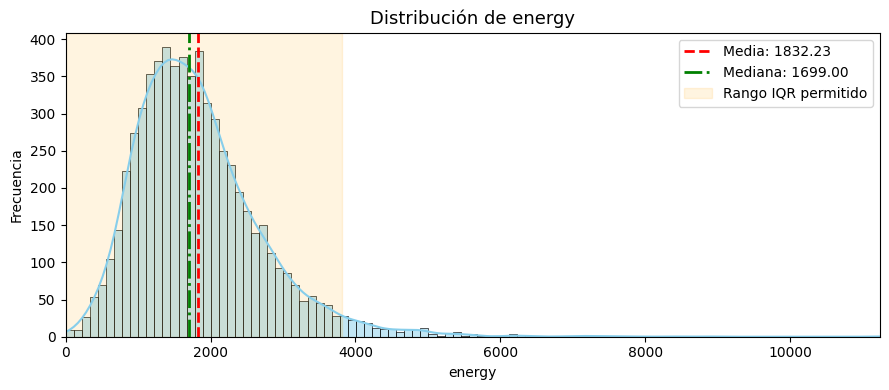

In [47]:
show_numerical_distribution('energy')

##### Analisis de outliers

| Grupo                 | kcal/día aproximadas |
| --------------------- | -------------------- |
| Niños pequeños        | 900 – 1600           |
| Adolescentes          | 1600 – 3200          |
| Adulto mujer          | 1600 – 2400          |
| Adulto hombre         | 2000 – 3200          |
| Muy activo/deportista | 3000 – 5000          |

Lo normal en este tipo de variables es que la mayoria de personas se encuentren en los mismos niveles y de que algunas personas tengan valores fuera de lo normal, por lo que se hará un analisis de los outliers para determinar si corresponden a nulos implicitos

In [48]:
nhanes_grupo1_df["energy"].sort_values(ascending=False).head(20)

1119    11241.0
4433     8860.0
8337     8351.0
6425     7812.0
6717     7485.0
510      7411.0
3083     7221.0
627      7151.0
1121     7076.0
4711     6892.0
2886     6496.0
5767     6317.0
7948     6236.0
6001     6157.0
7141     6148.0
6224     6146.0
8086     5722.0
694      5640.0
5754     5618.0
1412     5609.0
Name: energy, dtype: float64

Aunque hay valores superiores a los 5000 que son tomados como muy activos, no se van a considerar como nulos implicitos ya que para deportistas de muy alto rendimiento puede ser posible.

El valor que si es muy sospechoso y posiblemente un nulo implicito es 11241, ya que aparte de estar muy alejado del resto, es extremadamente alto.

In [49]:
nhanes_grupo1_df[nhanes_grupo1_df["energy"] == 11241]

,family_size,age,gender,taking_insulin,weight,height,bcu,sfa,db_pressure,protein,energy,health_condition
1119,1,59.0,Male,False,65.0,178.0,NaN,44.165,88.0,308.31,11241.0,Good


Teniendo en cuenta las demás variables de el individuo, una persona de 59 años con sus caracteristicas no es posible que tenga un valor de energia tan extrema, por lo cual es un **nulo implicito**

In [50]:
nhanes_grupo1_df = nhanes_grupo1_df.replace({
  'energy': { 11241: np.nan },
})

Ahora se revisarán los datos más bajos

In [51]:
nhanes_grupo1_df["energy"].sort_values(ascending=True).head(20)

582     5.397605e-79
5442    5.397605e-79
2583    1.900000e+01
1757    2.000000e+01
3923    7.400000e+01
3648    9.200000e+01
5963    1.030000e+02
1657    1.050000e+02
5209    1.050000e+02
3432    1.320000e+02
7581    1.360000e+02
2696    1.480000e+02
6545    1.560000e+02
308     1.580000e+02
1953    1.820000e+02
7580    1.820000e+02
525     2.200000e+02
7712    2.210000e+02
6210    2.240000e+02
7723    2.250000e+02
Name: energy, dtype: float64

Hay muchos datos muy bajos y que no tienen sentido fisiologico. Para hacer una pequeña mejora a los datos, se tomarán como nulos implicitos los valores menores a 100, ya que son valores imposibles.

In [52]:
mask_energy_low_100 = nhanes_grupo1_df['energy'] < 100

print('Cantidad de valores a convertir en nulos:', mask_energy_low_100.sum())

nhanes_grupo1_df.loc[mask_energy_low_100, 'energy'] = np.nan

print('Cantidad de valores < 100 después del cambio:', (nhanes_grupo1_df['energy'] < 100).sum())
print('Cantidad total de nulos en energy:', nhanes_grupo1_df['energy'].isna().sum())

Cantidad de valores a convertir en nulos: 6
Cantidad de valores < 100 después del cambio: 0
Cantidad total de nulos en energy: 2050


##### Conclusiones

- Solo hubo 1 outlier superior que era un nulo implicito.
- Los outliers inferiores a 100 si eran nulos implicitos, por lo cual se convirtieron 6 datos a nulos explicitos
- Se tenían originalmente 2050 datos faltantes, los cuales parecen ser MAR (Missing At Random).
- En total, quedaron 2056 datos nulos.
- Se usará Bosque Aleatorio para la imputación de los datos faltantes.


### Re-analisis despues de mejoras de las variables numericas

═════════════════════════════════════════════════════════════════
  age
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 0
IQR (Q3 - Q1): 47.0000
Rango actual [1.0000, 80.0000]
Rango IQR permitido [-58.5000, 129.5000]
Valores fuera del rango IQR: 0 de 8366


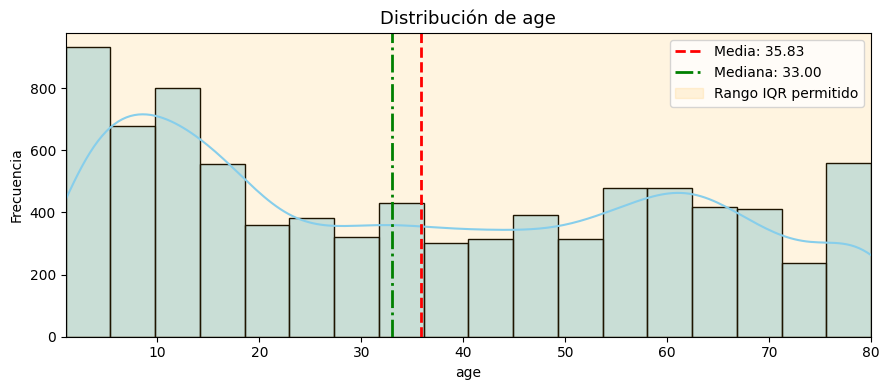

═════════════════════════════════════════════════════════════════
  weight
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 124
IQR (Q3 - Q1): 37.8000
Rango actual [8.3000, 242.6000]
Rango IQR permitido [-8.0000, 143.2000]
Valores fuera del rango IQR: 112 de 8242


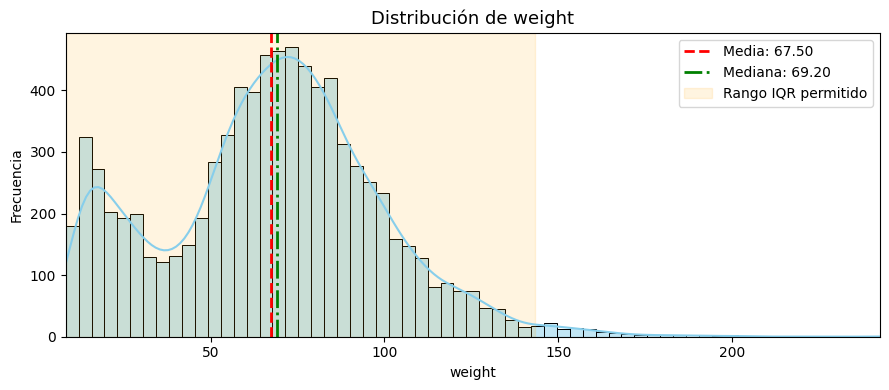

═════════════════════════════════════════════════════════════════
  height
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 350
IQR (Q3 - Q1): 19.8000
Rango actual [78.3000, 197.7000]
Rango IQR permitido [121.7000, 200.9000]
Valores fuera del rango IQR: 822 de 8016


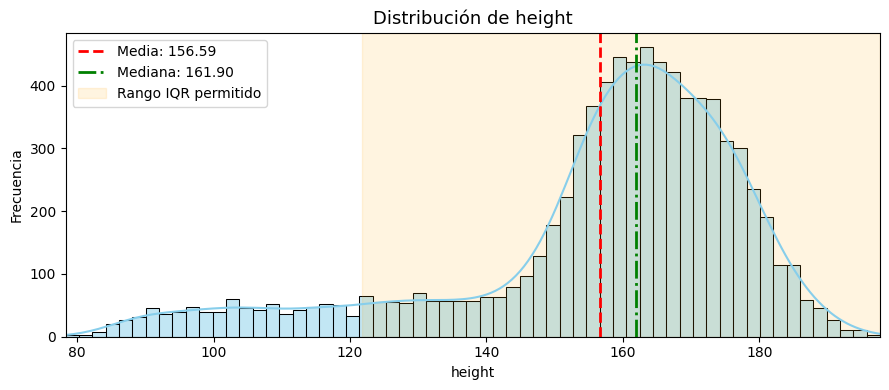

═════════════════════════════════════════════════════════════════
  bcu
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 853
IQR (Q3 - Q1): 0.3000
Rango actual [0.0700, 13.0300]
Rango IQR permitido [-0.3300, 0.8700]
Valores fuera del rango IQR: 677 de 7513


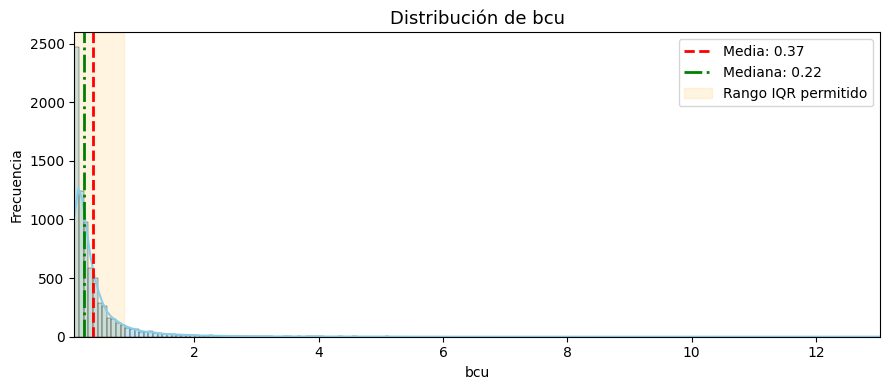

═════════════════════════════════════════════════════════════════
  sfa
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 1081
IQR (Q3 - Q1): 19.3920
Rango actual [0.0000, 195.8520]
Rango IQR permitido [-14.0990, 63.4690]
Valores fuera del rango IQR: 242 de 7285


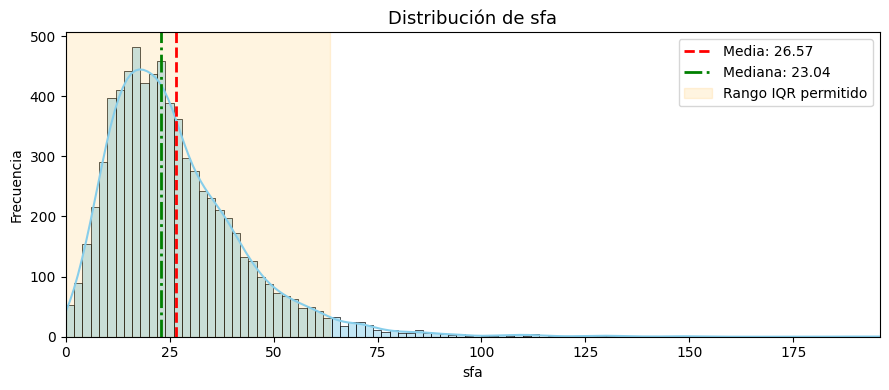

═════════════════════════════════════════════════════════════════
  db_pressure
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 1931
IQR (Q3 - Q1): 16.0000
Rango actual [20.0000, 136.0000]
Rango IQR permitido [38.0000, 102.0000]
Valores fuera del rango IQR: 115 de 6435


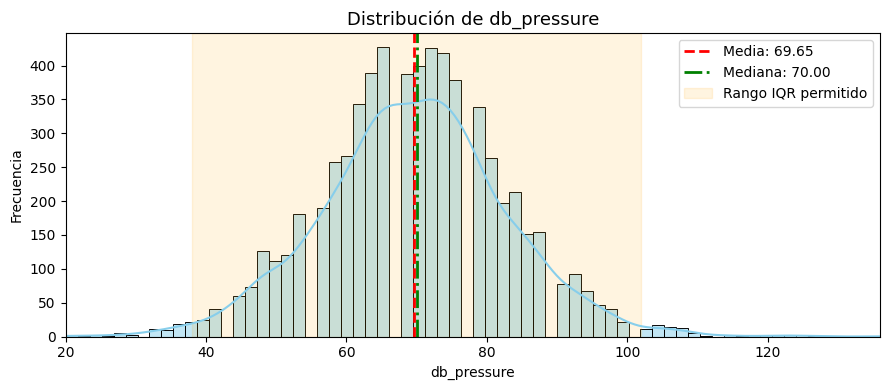

═════════════════════════════════════════════════════════════════
  protein
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 2047
IQR (Q3 - Q1): 43.0950
Rango actual [1.0600, 345.5300]
Rango IQR permitido [-19.6375, 152.7425]
Valores fuera del rango IQR: 227 de 6319


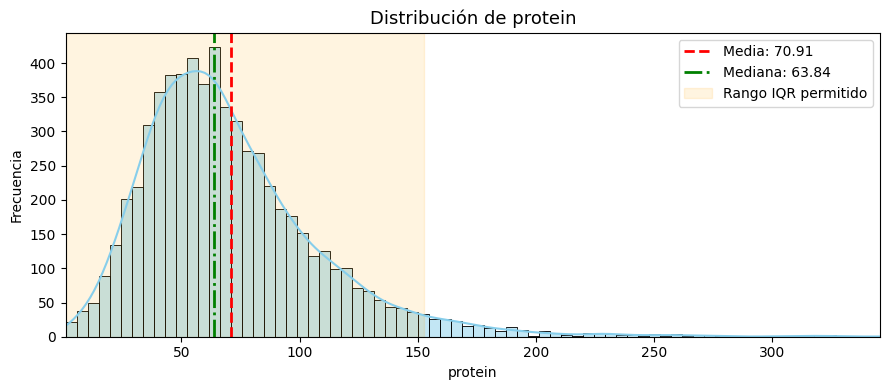

═════════════════════════════════════════════════════════════════
  energy
═════════════════════════════════════════════════════════════════
Cantidad de datos nulos: 2050
IQR (Q3 - Q1): 1035.0000
Rango actual [103.0000, 8860.0000]
Rango IQR permitido [-325.5000, 3814.5000]
Valores fuera del rango IQR: 191 de 6316


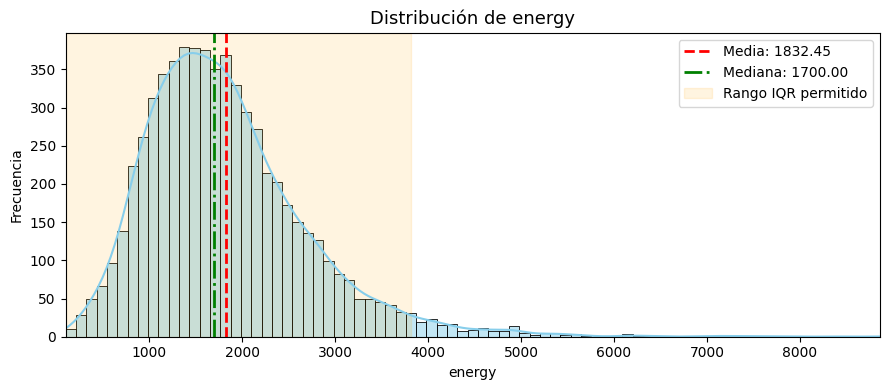

In [53]:
num_cols = nhanes_grupo1_df.select_dtypes(include=['number']).columns

for col in num_cols:
  show_numerical_distribution(col)

# Mecanismos de Imputación

In [54]:
from sklearn.experimental import enable_iterative_imputer

from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

## Función verificar imputación datos nulos

Se usará un grafico de matriz de sombra entre las variables db_pressure y energy ya que son de las variables con más datos faltantes.

Se intentó usar health_condition ya que era la que mas valores hacian falta, pero al ser categorica era mas complicado ver la distribución, por lo que se optó por las siguientes variables con datos faltantes.

In [55]:
def shadow_imputation_plot(df, df_origin=nhanes_grupo1_df, x='db_pressure', y='energy'):
  shadow_matrix = pd.concat(
    [
      df,
      df_origin.missing.create_shadow_matrix(True, False, suffix='_imp', only_missing=True)
    ],
    axis=1
  )

  display(shadow_matrix)

  shadow_matrix.missing.scatter_imputation_plot(x=x, y=y)
  plt.show()

## Simple por medidas de tendencia central

,family_size,age,gender,taking_insulin,weight,height,bcu,sfa,db_pressure,protein,...,health_condition,taking_insulin_imp,weight_imp,height_imp,bcu_imp,sfa_imp,db_pressure_imp,protein_imp,energy_imp,health_condition_imp
0,5,2.0,Female,False,13.7,88.6,0.22,23.037,70.0,63.84,...,Good,False,False,False,True,True,True,True,True,True
1,4,2.0,Male,False,13.9,94.2,0.07,11.372,70.0,30.49,...,Good,False,False,False,False,False,True,False,False,True
2,1,66.0,Female,False,79.5,158.3,0.24,16.435,70.0,38.52,...,Good,False,False,False,False,False,True,False,False,False
3,5,18.0,Male,False,66.3,175.7,0.21,35.169,70.0,63.84,...,Very good,False,False,False,False,False,False,True,True,False
4,7+,13.0,Male,False,45.4,158.4,0.14,33.252,46.0,92.03,...,Good,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,2,70.0,Female,False,49.0,156.5,0.61,7.652,78.0,47.56,...,Very good,False,False,False,False,False,False,False,False,False
8362,1,42.0,Male,False,97.4,164.9,0.21,25.831,76.0,63.84,...,Fair,False,False,False,False,False,False,True,True,False
8363,7+,41.0,Female,False,69.1,162.6,0.32,20.526,72.0,66.97,...,Good,False,False,False,False,False,False,False,False,False
8364,4,14.0,Female,False,111.9,156.6,0.11,23.027,60.0,58.08,...,Very good,False,False,False,False,False,False,False,False,False


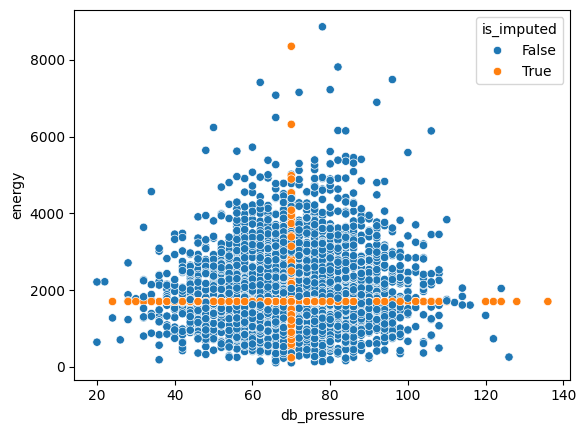

In [56]:
nhanes_grupo1_df_imputacion_simple = nhanes_grupo1_df.copy()

categorical_columns = nhanes_grupo1_df_imputacion_simple.select_dtypes(include=['object', 'category', 'str']).columns
numerical_columns = nhanes_grupo1_df_imputacion_simple.select_dtypes(include=['number']).columns

categorical_imputer = SimpleImputer(strategy='most_frequent')
numerical_imputer = SimpleImputer(strategy='median')

nhanes_grupo1_df_imputacion_simple[categorical_columns] = categorical_imputer.fit_transform(nhanes_grupo1_df_imputacion_simple[categorical_columns])
nhanes_grupo1_df_imputacion_simple[numerical_columns] = numerical_imputer.fit_transform(nhanes_grupo1_df_imputacion_simple[numerical_columns])

shadow_imputation_plot(nhanes_grupo1_df_imputacion_simple)

## Imputación por modelos de regresion

### Transformación variables

In [57]:
nhanes_grupo1_df_copy = nhanes_grupo1_df.copy()

categorical_columns = nhanes_grupo1_df_copy.select_dtypes(include=['object', 'string']).columns

categorical_transformer = (
  sklearn.compose
  .make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(), categorical_columns),
    remainder='passthrough'
  )
)

categorical_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinalencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.

In [58]:
nhanes_transformed_df = (
  pd.DataFrame(
    categorical_transformer.fit_transform(nhanes_grupo1_df_copy),
    columns=categorical_transformer.get_feature_names_out(),
    index=nhanes_grupo1_df_copy.index
  )
  .rename(columns=lambda x: x.replace('ordinalencoder__', ''))
  .rename(columns=lambda x: x.replace('remainder__', ''))
)

nhanes_transformed_df

,family_size,gender,taking_insulin,health_condition,age,weight,height,bcu,sfa,db_pressure,protein,energy
0,4.0,0.0,0.0,NaN,2.0,13.7,88.6,NaN,NaN,NaN,NaN,NaN
1,3.0,1.0,0.0,NaN,2.0,13.9,94.2,0.07,11.372,NaN,30.49,1356.0
2,0.0,0.0,0.0,2.0,66.0,79.5,158.3,0.24,16.435,NaN,38.52,1235.0
3,4.0,1.0,0.0,4.0,18.0,66.3,175.7,0.21,35.169,70.0,NaN,NaN
4,6.0,1.0,0.0,2.0,13.0,45.4,158.4,0.14,33.252,46.0,92.03,1794.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8361,1.0,0.0,0.0,4.0,70.0,49.0,156.5,0.61,7.652,78.0,47.56,1054.0
8362,0.0,1.0,0.0,1.0,42.0,97.4,164.9,0.21,25.831,76.0,NaN,NaN
8363,6.0,0.0,0.0,2.0,41.0,69.1,162.6,0.32,20.526,72.0,66.97,1835.0
8364,3.0,0.0,0.0,4.0,14.0,111.9,156.6,0.11,23.027,60.0,58.08,1617.0


### Vecinos Cercanos

,family_size,gender,taking_insulin,health_condition,age,weight,height,bcu,sfa,db_pressure,...,energy,taking_insulin_imp,weight_imp,height_imp,bcu_imp,sfa_imp,db_pressure_imp,protein_imp,energy_imp,health_condition_imp
0,4.0,0.0,0.0,2.0,2.0,14.0,89.0,0.0,21.0,54.0,...,1275.0,False,False,False,True,True,True,True,True,True
1,3.0,1.0,0.0,2.0,2.0,14.0,94.0,0.0,11.0,54.0,...,1356.0,False,False,False,False,False,True,False,False,True
2,0.0,0.0,0.0,2.0,66.0,80.0,158.0,0.0,16.0,87.0,...,1235.0,False,False,False,False,False,True,False,False,False
3,4.0,1.0,0.0,4.0,18.0,66.0,176.0,0.0,35.0,70.0,...,2081.0,False,False,False,False,False,False,True,True,False
4,6.0,1.0,0.0,2.0,13.0,45.0,158.0,0.0,33.0,46.0,...,1794.0,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,1.0,0.0,0.0,4.0,70.0,49.0,156.0,1.0,8.0,78.0,...,1054.0,False,False,False,False,False,False,False,False,False
8362,0.0,1.0,0.0,1.0,42.0,97.0,165.0,0.0,26.0,76.0,...,1607.0,False,False,False,False,False,False,True,True,False
8363,6.0,0.0,0.0,2.0,41.0,69.0,163.0,0.0,21.0,72.0,...,1835.0,False,False,False,False,False,False,False,False,False
8364,3.0,0.0,0.0,4.0,14.0,112.0,157.0,0.0,23.0,60.0,...,1617.0,False,False,False,False,False,False,False,False,False


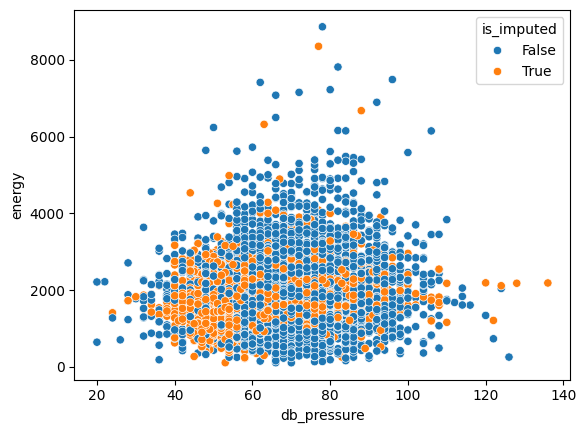

In [59]:
knn_imputer = KNNImputer()

nhanes_knn_df = DataFrame(
  knn_imputer.fit_transform(nhanes_transformed_df).round(),
  columns=nhanes_transformed_df.columns,
  index=nhanes_transformed_df.index
)

shadow_imputation_plot(nhanes_knn_df)

### Modelos de Regresión

#### Regresión Lineal

,family_size,gender,taking_insulin,health_condition,age,weight,height,bcu,sfa,db_pressure,...,energy,taking_insulin_imp,weight_imp,height_imp,bcu_imp,sfa_imp,db_pressure_imp,protein_imp,energy_imp,health_condition_imp
0,4.0,0.0,0.0,2.0,2.0,14.0,89.0,0.0,15.0,43.0,...,1069.0,False,False,False,True,True,True,True,True,True
1,3.0,1.0,0.0,2.0,2.0,14.0,94.0,0.0,11.0,44.0,...,1356.0,False,False,False,False,False,True,False,False,True
2,0.0,0.0,0.0,2.0,66.0,80.0,158.0,0.0,16.0,72.0,...,1235.0,False,False,False,False,False,True,False,False,False
3,4.0,1.0,0.0,4.0,18.0,66.0,176.0,0.0,35.0,70.0,...,2245.0,False,False,False,False,False,False,True,True,False
4,6.0,1.0,0.0,2.0,13.0,45.0,158.0,0.0,33.0,46.0,...,1794.0,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,1.0,0.0,0.0,4.0,70.0,49.0,156.0,1.0,8.0,78.0,...,1054.0,False,False,False,False,False,False,False,False,False
8362,0.0,1.0,0.0,1.0,42.0,97.0,165.0,0.0,26.0,76.0,...,2041.0,False,False,False,False,False,False,True,True,False
8363,6.0,0.0,0.0,2.0,41.0,69.0,163.0,0.0,21.0,72.0,...,1835.0,False,False,False,False,False,False,False,False,False
8364,3.0,0.0,0.0,4.0,14.0,112.0,157.0,0.0,23.0,60.0,...,1617.0,False,False,False,False,False,False,False,False,False


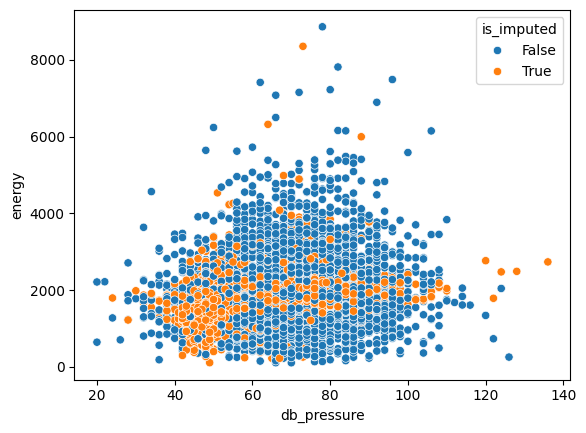

In [60]:
mice_imputer_linear = IterativeImputer(
  estimator=LinearRegression(),
)

nhanes_mice_linear_df = pd.DataFrame(
  mice_imputer_linear.fit_transform(nhanes_transformed_df).round(),
  columns=nhanes_transformed_df.columns,
  index=nhanes_transformed_df.index
)

shadow_imputation_plot(nhanes_mice_linear_df)

#### Árbol de Decisión

,family_size,gender,taking_insulin,health_condition,age,weight,height,bcu,sfa,db_pressure,...,energy,taking_insulin_imp,weight_imp,height_imp,bcu_imp,sfa_imp,db_pressure_imp,protein_imp,energy_imp,health_condition_imp
0,4.0,0.0,0.0,0.0,2.0,14.0,89.0,0.0,14.0,76.0,...,753.0,False,False,False,True,True,True,True,True,True
1,3.0,1.0,0.0,0.0,2.0,14.0,94.0,0.0,11.0,60.0,...,1356.0,False,False,False,False,False,True,False,False,True
2,0.0,0.0,0.0,2.0,66.0,80.0,158.0,0.0,16.0,90.0,...,1235.0,False,False,False,False,False,True,False,False,False
3,4.0,1.0,0.0,4.0,18.0,66.0,176.0,0.0,35.0,70.0,...,1876.0,False,False,False,False,False,False,True,True,False
4,6.0,1.0,0.0,2.0,13.0,45.0,158.0,0.0,33.0,46.0,...,1794.0,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,1.0,0.0,0.0,4.0,70.0,49.0,156.0,1.0,8.0,78.0,...,1054.0,False,False,False,False,False,False,False,False,False
8362,0.0,1.0,0.0,1.0,42.0,97.0,165.0,0.0,26.0,76.0,...,811.0,False,False,False,False,False,False,True,True,False
8363,6.0,0.0,0.0,2.0,41.0,69.0,163.0,0.0,21.0,72.0,...,1835.0,False,False,False,False,False,False,False,False,False
8364,3.0,0.0,0.0,4.0,14.0,112.0,157.0,0.0,23.0,60.0,...,1617.0,False,False,False,False,False,False,False,False,False


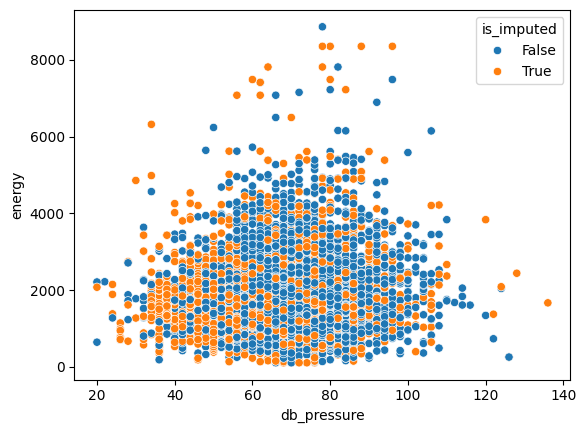

In [61]:
mice_imputer_dcr = IterativeImputer(
  estimator=DecisionTreeRegressor(),
)

nhanes_mice_dcr_df = DataFrame(
  mice_imputer_dcr.fit_transform(nhanes_transformed_df).round(),
  columns=nhanes_transformed_df.columns,
  index=nhanes_transformed_df.index
)

shadow_imputation_plot(nhanes_mice_dcr_df)

#### Bosque Aleatorio 

,family_size,gender,taking_insulin,health_condition,age,weight,height,bcu,sfa,db_pressure,...,energy,taking_insulin_imp,weight_imp,height_imp,bcu_imp,sfa_imp,db_pressure_imp,protein_imp,energy_imp,health_condition_imp
0,4.0,0.0,0.0,1.0,2.0,14.0,89.0,0.0,18.0,62.0,...,1260.0,False,False,False,True,True,True,True,True,True
1,3.0,1.0,0.0,2.0,2.0,14.0,94.0,0.0,11.0,61.0,...,1356.0,False,False,False,False,False,True,False,False,True
2,0.0,0.0,0.0,2.0,66.0,80.0,158.0,0.0,16.0,71.0,...,1235.0,False,False,False,False,False,True,False,False,False
3,4.0,1.0,0.0,4.0,18.0,66.0,176.0,0.0,35.0,70.0,...,2837.0,False,False,False,False,False,False,True,True,False
4,6.0,1.0,0.0,2.0,13.0,45.0,158.0,0.0,33.0,46.0,...,1794.0,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,1.0,0.0,0.0,4.0,70.0,49.0,156.0,1.0,8.0,78.0,...,1054.0,False,False,False,False,False,False,False,False,False
8362,0.0,1.0,0.0,1.0,42.0,97.0,165.0,0.0,26.0,76.0,...,2229.0,False,False,False,False,False,False,True,True,False
8363,6.0,0.0,0.0,2.0,41.0,69.0,163.0,0.0,21.0,72.0,...,1835.0,False,False,False,False,False,False,False,False,False
8364,3.0,0.0,0.0,4.0,14.0,112.0,157.0,0.0,23.0,60.0,...,1617.0,False,False,False,False,False,False,False,False,False


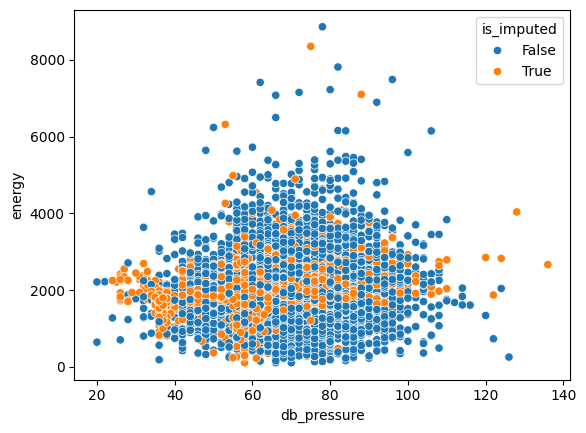

In [62]:
mice_imputer_rfr = IterativeImputer(
  estimator=RandomForestRegressor(),
)

nhanes_mice_rfr_df = DataFrame(
  mice_imputer_rfr.fit_transform(nhanes_transformed_df).round(),
  columns=nhanes_transformed_df.columns,
  index=nhanes_transformed_df.index
)

shadow_imputation_plot(nhanes_mice_rfr_df)

#### Red Neuronal Perceptrón 

,family_size,gender,taking_insulin,health_condition,age,weight,height,bcu,sfa,db_pressure,...,energy,taking_insulin_imp,weight_imp,height_imp,bcu_imp,sfa_imp,db_pressure_imp,protein_imp,energy_imp,health_condition_imp
0,4.0,0.0,0.0,1.0,2.0,14.0,89.0,-0.0,17.0,34.0,...,1207.0,False,False,False,True,True,True,True,True,True
1,3.0,1.0,0.0,1.0,2.0,14.0,94.0,0.0,11.0,35.0,...,1356.0,False,False,False,False,False,True,False,False,True
2,0.0,0.0,0.0,2.0,66.0,80.0,158.0,0.0,16.0,70.0,...,1235.0,False,False,False,False,False,True,False,False,False
3,4.0,1.0,0.0,4.0,18.0,66.0,176.0,0.0,35.0,70.0,...,2475.0,False,False,False,False,False,False,True,True,False
4,6.0,1.0,0.0,2.0,13.0,45.0,158.0,0.0,33.0,46.0,...,1794.0,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,1.0,0.0,0.0,4.0,70.0,49.0,156.0,1.0,8.0,78.0,...,1054.0,False,False,False,False,False,False,False,False,False
8362,0.0,1.0,0.0,1.0,42.0,97.0,165.0,0.0,26.0,76.0,...,2122.0,False,False,False,False,False,False,True,True,False
8363,6.0,0.0,0.0,2.0,41.0,69.0,163.0,0.0,21.0,72.0,...,1835.0,False,False,False,False,False,False,False,False,False
8364,3.0,0.0,0.0,4.0,14.0,112.0,157.0,0.0,23.0,60.0,...,1617.0,False,False,False,False,False,False,False,False,False


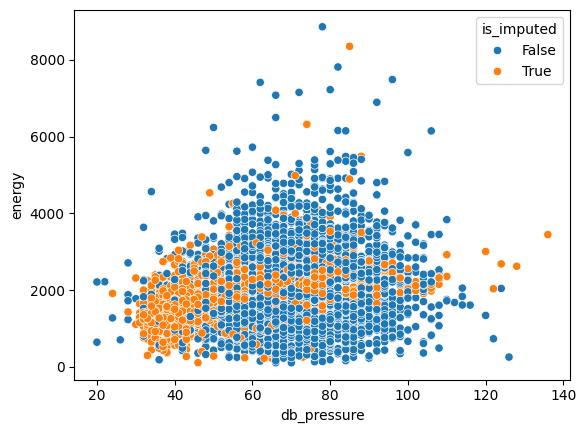

In [63]:
mice_imputer_mlp = IterativeImputer(
  estimator=MLPRegressor(),
)

nhanes_mice_mlp_df = pd.DataFrame(
  mice_imputer_mlp.fit_transform(nhanes_transformed_df).round(),
  columns=nhanes_transformed_df.columns,
  index=nhanes_transformed_df.index
)

shadow_imputation_plot(nhanes_mice_mlp_df)

### Retornar valores con el transformer

In [65]:
selected_model = nhanes_mice_dcr_df

In [66]:
nhanes_imputed_df = selected_model

nhanes_imputed_df[categorical_columns] = (
  categorical_transformer
  .named_transformers_
  .ordinalencoder
  .inverse_transform(
    X = selected_model[categorical_columns].to_numpy(copy=True)
  )
)

nhanes_imputed_df

,family_size,gender,taking_insulin,health_condition,age,weight,height,bcu,sfa,db_pressure,protein,energy
0,5,Female,False,Excellent,2.0,14.0,89.0,0.0,14.0,76.0,20.0,753.0
1,4,Male,False,Excellent,2.0,14.0,94.0,0.0,11.0,60.0,30.0,1356.0
2,1,Female,False,Good,66.0,80.0,158.0,0.0,16.0,90.0,39.0,1235.0
3,5,Male,False,Very good,18.0,66.0,176.0,0.0,35.0,70.0,69.0,1876.0
4,7+,Male,False,Good,13.0,45.0,158.0,0.0,33.0,46.0,92.0,1794.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8361,2,Female,False,Very good,70.0,49.0,156.0,1.0,8.0,78.0,48.0,1054.0
8362,1,Male,False,Fair,42.0,97.0,165.0,0.0,26.0,76.0,47.0,811.0
8363,7+,Female,False,Good,41.0,69.0,163.0,0.0,21.0,72.0,67.0,1835.0
8364,4,Female,False,Very good,14.0,112.0,157.0,0.0,23.0,60.0,58.0,1617.0


# Analisis variables despues de la imputación de datos

## Variables categoricas

In [70]:
print("Resumen de variables categóricas antes de la imputación:")
display(nhanes_grupo1_df.describe(include=['object', 'str']).transpose())

print("\n Resumen de variables categóricas despues de la imputación:")
display(nhanes_imputed_df.describe(include=['object', 'str']).transpose())

Resumen de variables categóricas antes de la imputación:


,count,unique,top,freq
family_size,8366,7,4,1658
gender,8366,2,Female,4272
taking_insulin,8365,2,False,8118
health_condition,5964,5,Good,2454



 Resumen de variables categóricas despues de la imputación:


,count,unique,top,freq
family_size,8366,7,4,1658
gender,8366,2,Female,4272
taking_insulin,8366,2,False,8119
health_condition,8366,5,Good,2896


## Variables numericas

In [71]:
print("Resumen de variables numericas antes de la imputación:")
display(nhanes_grupo1_df.describe().transpose())

print("Resumen de variables numericas despues de la imputación:")
display(nhanes_imputed_df.describe().transpose())

Resumen de variables numericas antes de la imputación:


,count,mean,std,min,25%,50%,75%,max
age,8366.0,35.830026,24.905061,1.000000e+00,12.000,33.000,59.000,80.000
weight,8242.0,67.499260,31.377152,8.300000e+00,48.700,69.200,86.500,242.600
height,8016.0,156.593401,22.257858,7.830000e+01,151.400,161.900,171.200,197.700
bcu,7513.0,0.373626,0.503434,7.000000e-02,0.120,0.220,0.420,13.030
sfa,7285.0,26.566194,17.065502,5.397605e-79,14.989,23.037,34.381,195.852
db_pressure,6435.0,69.651282,13.130804,2.000000e+01,62.000,70.000,78.000,136.000
protein,6319.0,70.911345,38.400187,1.060000e+00,45.005,63.840,88.100,345.530
energy,6316.0,1832.445218,877.005031,1.030000e+02,1227.000,1700.000,2262.000,8860.000


Resumen de variables numericas despues de la imputación:


,count,mean,std,min,25%,50%,75%,max
age,8366.0,35.830026,24.905061,1.0,12.0,33.0,59.0,80.0
weight,8366.0,67.496653,31.417561,8.0,49.0,69.0,86.0,243.0
height,8366.0,154.678460,24.724952,78.0,150.0,161.0,171.0,198.0
bcu,8366.0,0.233206,0.574827,0.0,0.0,0.0,0.0,13.0
sfa,8366.0,26.279106,16.871220,0.0,15.0,23.0,34.0,196.0
db_pressure,8366.0,67.253646,14.110976,20.0,58.0,68.0,76.0,136.0
protein,8366.0,70.953024,39.774256,1.0,44.0,63.0,88.0,346.0
energy,8366.0,1832.735836,910.937206,103.0,1216.0,1686.0,2257.0,8860.0


## Comparación datos imputados entre modelos

In [72]:
target_variable = 'protein'

null_indices = nhanes_grupo1_df[nhanes_grupo1_df[target_variable].isnull()].index

imputed_values_comparison = pd.DataFrame(index=null_indices)

imputed_values_comparison['Simple_Imputer'] = nhanes_grupo1_df_imputacion_simple.loc[null_indices, target_variable]
imputed_values_comparison['KNN_Imputer'] = nhanes_knn_df.loc[null_indices, target_variable]
imputed_values_comparison['MICE_Linear'] = nhanes_mice_linear_df.loc[null_indices, target_variable]
imputed_values_comparison['MICE_DCR'] = nhanes_mice_dcr_df.loc[null_indices, target_variable]
imputed_values_comparison['MICE_RFR'] = nhanes_mice_rfr_df.loc[null_indices, target_variable]
imputed_values_comparison['MICE_MLP'] = nhanes_mice_mlp_df.loc[null_indices, target_variable]

print(f"Comparación de valores imputados para los primeros 10 nulos de la variable '{target_variable}':")
display(imputed_values_comparison.head(10))

Comparación de valores imputados para los primeros 10 nulos de la variable 'protein':


,Simple_Imputer,KNN_Imputer,MICE_Linear,MICE_DCR,MICE_RFR,MICE_MLP
0,63.84,41.0,37.0,20.0,47.0,43.0
3,63.84,118.0,87.0,69.0,113.0,93.0
6,63.84,68.0,61.0,39.0,85.0,73.0
14,63.84,64.0,78.0,36.0,80.0,80.0
21,63.84,54.0,59.0,185.0,61.0,74.0
26,63.84,69.0,84.0,11.0,76.0,89.0
32,63.84,74.0,72.0,38.0,56.0,76.0
40,63.84,56.0,58.0,90.0,63.0,59.0
43,63.84,39.0,45.0,39.0,54.0,48.0
44,63.84,76.0,54.0,44.0,60.0,66.0


# Conclusión Imputación de nulos

Se compararon los métodos de imputación (Simple, KNN, MICE con Regresión Lineal, Árbol de Decisión, Bosque Aleatorio y MLP) y se evaluó su comportamiento con matriz de sombra y consistencia de valores imputados.

Se determinó desde una perpectiva visual por la matriz de sombra de que el mejor modelo fue el **Árbol de Decisión** ya que es el que mayor distribución de los datos tiene.

![Resultado Decision Tree Regressor](decision_tree_regressor_result.png)

Aunque el grafico solo permite ver 2 variables al tiempo, al ser estas de las que más faltantes habían, se puede concluir en base a estas.